In [5]:
import pickle
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [6]:
DOCUMENT_PATH = "../data/documents.pkl"

In [7]:
with open(DOCUMENT_PATH, "rb") as file:
    documents = pickle.load(file)

print(f"Loaded {len(documents)} documents.")

Loaded 489 documents.


In [8]:
documents[0]

Document(metadata={'source': 'FAQ', 'category': 'Order Tracking'}, page_content='\nQuestion:\nCan I track multiple orders?\n\nAnswer:\nYes, each order has its own tracking information in your account.\n')

In [9]:
print(documents[0].page_content)


Question:
Can I track multiple orders?

Answer:
Yes, each order has its own tracking information in your account.



In [10]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=100,
    separators=[
        "\n\n",
        "\n",
        ". ",
        " ",
        ""
    ]
)

In [11]:
chunks = text_splitter.split_documents(documents)

print(f"Total Chunks Created: {len(chunks)}")

Total Chunks Created: 494


In [12]:
chunks[0]

Document(metadata={'source': 'FAQ', 'category': 'Order Tracking'}, page_content='Question:\nCan I track multiple orders?\n\nAnswer:\nYes, each order has its own tracking information in your account.')

In [13]:
print(chunks[0].page_content)

Question:
Can I track multiple orders?

Answer:
Yes, each order has its own tracking information in your account.


In [ ]:
for i in range(3):
    print("=" * 80)
    print(f"Chunk {i+1}")
    print()
    print(chunks[i].page_content)
    print()

Chunk 1

Question:
Can I track multiple orders?

Answer:
Yes, each order has its own tracking information in your account.

Chunk 2

Question:
Why hasn't my order shipped?

Answer:
Orders are usually processed within 24 hours. Delays may occur during peak periods.

Chunk 3

Question:
Where is my order?

Answer:
You can track your order from the 'My Orders' section using your tracking number.



In [15]:
chunk_lengths = [len(chunk.page_content) for chunk in chunks]
print("Total Chunks :", len(chunk_lengths))
print("Average Size :", round(sum(chunk_lengths)/len(chunk_lengths),2))
print("Minimum Size :", min(chunk_lengths))
print("Maximum Size :", max(chunk_lengths))

Total Chunks : 494
Average Size : 116.77
Minimum Size : 71
Maximum Size : 500


In [16]:
import pandas as pd

stats = pd.DataFrame({

    "Chunk Number": range(1, len(chunk_lengths)+1),

    "Characters": chunk_lengths

})

stats.head()

,Chunk Number,Characters
0,1,113
1,2,131
2,3,119
3,4,117
4,5,115


In [17]:
stats.describe()

,Chunk Number,Characters
count,494.000000,494.000000
mean,247.500000,116.765182
std,142.749781,36.919812
min,1.000000,71.000000
25%,124.250000,106.000000
50%,247.500000,114.000000
75%,370.750000,120.000000
max,494.000000,500.000000


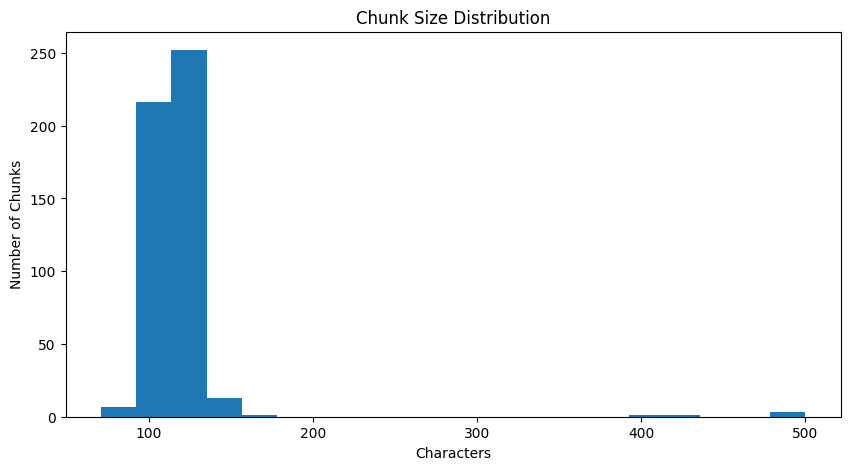

In [18]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.hist(chunk_lengths, bins=20)
plt.title("Chunk Size Distribution")
plt.xlabel("Characters")
plt.ylabel("Number of Chunks")
plt.show()

In [19]:
CHUNK_PATH = "../data/document_chunks.pkl"
with open(CHUNK_PATH, "wb") as file:
    pickle.dump(chunks, file)
print("Chunked documents saved successfully.")

Chunked documents saved successfully.


In [20]:
with open(CHUNK_PATH, "rb") as file:
    loaded_chunks = pickle.load(file)
print(f"Loaded {len(loaded_chunks)} chunks.")

Loaded 494 chunks.


In [21]:
loaded_chunks[0]

Document(metadata={'source': 'FAQ', 'category': 'Order Tracking'}, page_content='Question:\nCan I track multiple orders?\n\nAnswer:\nYes, each order has its own tracking information in your account.')